In [155]:
import pyuvdata
import numpy as np
import matplotlib.pyplot as plt
from calico import calibration_wrappers

In [156]:
uv = pyuvdata.UVData()
uv.read("/Users/ruby/Downloads/20260419_055641-055832_44MHz_selfcal_calibrated.ms")

In [157]:
uv.Nfreqs

295

In [158]:
np.shape(uv.flag_array)

(745536, 295, 4)

In [159]:
uv.select(polarizations=[-5], inplace=True)

In [160]:
print(uv.polarization_array)

[-5]


In [161]:
uv.data_array[np.where(uv.flag_array)] = np.nan + 1*np.nan

In [162]:
uv.downsample_in_time(n_times_to_avg=12)

In [163]:
flags_per_freq = np.sum(uv.flag_array, axis=(0,2))

In [164]:
np.where(flags_per_freq == np.min(flags_per_freq))

(array([203, 204, 205, 206, 208, 209, 210, 211, 212, 213, 215, 217, 219,
        220, 223, 238, 239, 241, 242, 243, 244, 245, 248, 249, 250, 251,
        252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264,
        265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277, 278,
        282, 283, 284, 285, 286, 287, 288, 289, 291, 292]),)

In [165]:
uv.select(freq_chans=[251])

In [166]:
antpos = uv.telescope.get_enu_antpos()

In [167]:
antpos

array([[-2.63802065e+02,  2.97376191e+02,  8.47599972e-01],
       [-2.29295245e+02,  9.23794682e+02,  1.35879325e+00],
       [-2.96895042e+02,  3.70995527e+02,  1.17227911e+00],
       ...,
       [-7.90131455e+02,  8.49292432e+02,  1.33442206e+00],
       [-9.61875071e+02, -2.54490397e+02, -5.32751862e+00],
       [-1.40646457e+02, -7.08274589e+01, -2.51942913e-01]])

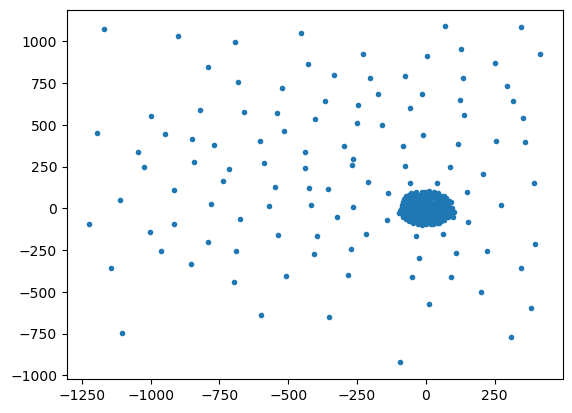

In [168]:
plt.plot(antpos[:, 0], antpos[:, 1], ".")
ant_dist = np.sqrt(antpos[:, 0]**2 + antpos[:, 1]**2)

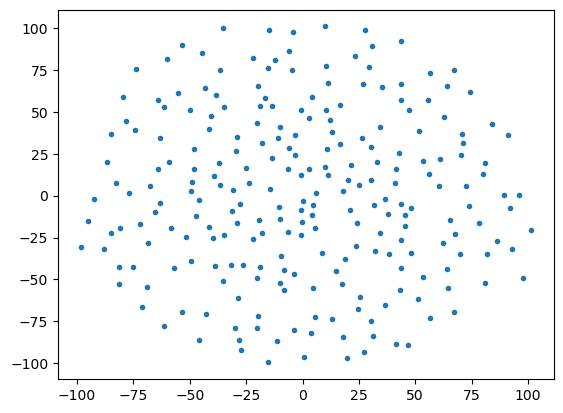

In [169]:
plt.plot(antpos[np.where(ant_dist < 120)[0], 0], antpos[np.where(ant_dist < 120)[0], 1], ".")

In [170]:
keep_ants = np.array(uv.telescope.antenna_names)[np.where(ant_dist < 120)[0]]

In [171]:
keep_ants

array(['LWA002', 'LWA001', 'LWA004', 'LWA003', 'LWA006', 'LWA005',
       'LWA009', 'LWA007', 'LWA011', 'LWA010', 'LWA012', 'LWA008',
       'LWA040', 'LWA038', 'LWA042', 'LWA041', 'LWA044', 'LWA043',
       'LWA046', 'LWA045', 'LWA071', 'LWA047', 'LWA074', 'LWA073',
       'LWA077', 'LWA075', 'LWA013', 'LWA016', 'LWA015', 'LWA014',
       'LWA018', 'LWA017', 'LWA020', 'LWA019', 'LWA022', 'LWA021',
       'LWA024', 'LWA023', 'LWA026', 'LWA025', 'LWA029', 'LWA027',
       'LWA049', 'LWA048', 'LWA051', 'LWA050', 'LWA053', 'LWA052',
       'LWA054', 'LWA080', 'LWA084', 'LWA055', 'LWA030', 'LWA028',
       'LWA032', 'LWA031', 'LWA063', 'LWA060', 'LWA057', 'LWA056',
       'LWA059', 'LWA058', 'LWA062', 'LWA061', 'LWA085', 'LWA064',
       'LWA087', 'LWA086', 'LWA089', 'LWA096', 'LWA091', 'LWA090',
       'LWA093', 'LWA092', 'LWA095', 'LWA094', 'LWA122', 'LWA121',
       'LWA035', 'LWA033', 'LWA034', 'LWA036', 'LWA066', 'LWA065',
       'LWA068', 'LWA067', 'LWA070', 'LWA069', 'LWA097', 'LWA0

In [172]:
uv.select(antenna_names=keep_ants)

In [173]:
#uv.write_ms("/Users/ruby/Downloads/data.ms", fix_autos=True)

In [174]:
np.sum(uv.flag_array)

5436

In [175]:
np.shape(uv.data_array)

(28441, 1, 1)

In [176]:
cal = calibration_wrappers.sky_based_calibration_wrapper(uv.copy(), uv.copy(), maxiter=1)

The entry name zenith_at_jd2461149.748347 is not unique inside the phase center catalog, adding anyways.


In [177]:
cal.gain_array

array([[[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[nan+nanj]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[nan+nanj]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[nan+nanj]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[nan+nanj]]],


       [[[nan+nanj]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[ 1. +0.j]]],


       [[[nan+nanj]]],




In [178]:
cal.antenna_names[np.where(~np.isfinite(cal.gain_array[:, 0, 0, 0]))]

array(['LWA004', 'LWA005', 'LWA040', 'LWA015', 'LWA014', 'LWA025',
       'LWA086', 'LWA122', 'LWA068', 'LWA069', 'LWA107', 'LWA110',
       'LWA112', 'LWA111', 'LWA143', 'LWA124', 'LWA159', 'LWA224',
       'LWA227', 'LWA234', 'LWA206', 'LWA210', 'LWA235', 'LWA221'],
      dtype='<U6')

In [179]:
uv.Nblts

28441

In [180]:
uv.select(antenna_names = list(cal.antenna_names[np.where(np.isfinite(cal.gain_array[:, 0, 0, 0]))]))

In [181]:
cal = calibration_wrappers.sky_based_calibration_wrapper(uv.copy(), uv.copy(), maxiter=1)

The entry name zenith_at_jd2461149.748347 is not unique inside the phase center catalog, adding anyways.


In [182]:
np.max(cal.gain_array)  # Check for nans

(1+0j)

In [183]:
gain_amp_stddev = 0.1
#for iter_ind in range(10000):
for iter_ind in range(10, 10000):
    cal.gain_array = (
        np.random.normal(loc=1.0, scale=gain_amp_stddev, size=np.shape(cal.gain_array)) 
        * np.exp(1j*np.random.uniform(low=0, high=2*np.pi, size=np.shape(cal.gain_array)))
    )
    new_uv = pyuvdata.utils.uvcalibrate(uv, cal, inplace=False, time_check=False)
    cal.gain_convention = "divide"
    cal.write_calfits(f"/Users/ruby/Downloads/cs163_data/gains_{iter_ind}.calfits")
    new_uv.write_uvfits(f"/Users/ruby/Downloads/cs163_data/uncalib_data_{iter_ind}.uvfits")

gain_scale is not set, so there is no way to know what the resulting units are. For now, we assume that `gain_scale` matches whatever is on the UVData object (i.e. we do not change its units). Furthermore, all corrections concerning the pol_convention will be ignored.
pol_convention is not specified on the UVCal object, and uvc_pol_convention was not specified. Tentatively assuming that the UVCal and UVData objects (implicitly) have the same convention.
Neither uvd_pol_convention nor uvc_pol_convention are specified, so the resulting UVData object will have ambiguous convention. 
antnums_to_baseline: found antenna numbers > 255, using 2048 baseline indexing.
Found antenna numbers > 255 in this data set. This is permitted by UVFITS standards, but may cause the `importuvfits` utility within CASA to crash. If attempting to use this data set in CASA, consider using the measurement set writer method (`write_ms`) instead.
gain_scale is not set, so there is no way to know what the resulting u